# Proyecto Integrador Final — Notebook de evidencias y análisis
**Grupo 1:** Alexis Rivera, Lissette Adriano, Shirley Adriano, Cristian Solís · ESPOCH · M1721

Este notebook **no recalcula a mano ningún número del informe**: consulta en vivo PostgreSQL y MongoDB,
lee las salidas generadas por `run_pipeline.py` y re-ajusta el modelo principal para demostrar
que el resultado es reproducible. Se ejecuta automáticamente como etapa 10 del pipeline.

> Convención: las variables con prefijo `sim_` y todo lo que proviene de MongoDB es **SIMULADO**
> (demostración del pipeline). Los hallazgos sustantivos se basan solo en el registro real UCI.

In [1]:
import sys, json, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
from sqlalchemy import create_engine, text
from pymongo import MongoClient
from IPython.display import Image, display
import config
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 200)
print('SEED =', config.SEED)

SEED = 42


## 1. Evidencia de ejecución: conteos por etapa (logs/ultima_ejecucion.json)

In [2]:
log = json.loads((ROOT / 'logs' / 'ultima_ejecucion.json').read_text())
pd.DataFrame(log['etapas']).T.drop(columns=[c for c in ['sha256'] if c in pd.DataFrame(log['etapas']).T.columns]).dropna(how='all', axis=1).head(40)

,filas_leidas,columnas,filas_totales,duracion_s,filas_uci,claves_comunes,claves_distintas_mat,claves_distintas_por,claves_distintas_union,grupos_clave_repetida,filas_perdidas_si_fusion,filas_merge_ingenuo,pares_aceptados,pares_etapa1,pares_etapa2,...,alertas_riesgo_bytes,seguimiento_riesgo_indices_bytes,alertas_riesgo_indices_bytes,filas,en_riesgo,prevalencia,train,test,variables_simuladas,figuras,exactitud_texto,auc_test_A_logistica,escalas,filas_max,t_agregacion_max_s
extract_MAT,395,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
extract_POR,649,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
extract,NaN,NaN,1044.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1_extract,NaN,NaN,NaN,0.053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
identidad,NaN,NaN,NaN,NaN,1044.0,366.0,391.0,637.0,662.0,15.0,16.0,382.0,370.0,358.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transform_uci,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2_transform_uci,NaN,NaN,NaN,0.251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
generate_synthetic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3_generate_synthetic,NaN,NaN,NaN,0.677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clean_lms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
pd.read_csv(ROOT / 'logs' / 'reglas_calidad.csv')[['id','fuente','descripcion','afectados']]

,id,fuente,descripcion,afectados
0,R-01,F1 UCI,Esquema: 33 columnas esperadas y tipos declarados,0
1,R-02,F1 UCI,Valores faltantes en las 33 columnas,0
2,R-03,F1 UCI,Filas duplicadas exactas (33 columnas) dentro ...,0
3,R-04,F1 UCI,Valores categóricos fuera del catálogo UCI,0
4,R-05,F1 UCI,Valores numéricos fuera de rango documentado,0
5,R-11,F1 UCI,Clave de 13 atributos repetida dentro del mism...,31
6,R-12,F1 UCI,Emparejamiento MAT-POR: 366 claves comunes; me...,370
7,R-13,F1 UCI,Conflictos en atributos personales entre filas...,0
8,R-12b,F1 UCI,Posibles falsos negativos: filas sin pareja qu...,5
9,R-06,F1 UCI,Estandarización: 8 binarias yes/no -> booleano...,1044


## 2. PostgreSQL en vivo: integridad y consulta analítica de P1 (JOIN + agregación)

In [4]:
eng = create_engine(config.pg_url())
with eng.connect() as con:
    print(con.execute(text('SHOW server_version')).scalar())
    display(pd.read_sql(text('''SELECT table_name, (xpath('/row/c/text()', query_to_xml('SELECT COUNT(*) AS c FROM academico.'||table_name, false, true, '')))[1]::text::int AS filas
                               FROM information_schema.tables WHERE table_schema='academico' AND table_type='BASE TABLE' ORDER BY 1'''), con))

18.6


,table_name,filas
0,asignatura,2
1,calificacion,3132
2,escuela,2
3,estudiante,674
4,matricula,1044
5,periodo,3


In [5]:
from load import consultas_nombradas
with eng.connect() as con:
    for nombre, q in consultas_nombradas(ROOT / 'sql' / '04_analiticas.sql')[:2]:
        print(nombre); display(pd.read_sql(text(q), con))

A-01 Nota media por asignatura y período (excluye no evaluados, R-08)


,asignatura,periodo,n_evaluados,media,desv_est,mediana,n_no_evaluados
0,MAT,P1,395,10.91,3.32,11.0,0
1,MAT,P2,382,11.08,3.25,11.0,13
2,MAT,P3,357,11.52,3.23,11.0,38
3,POR,P1,648,11.42,2.71,11.0,1
4,POR,P2,642,11.70,2.67,11.0,7
5,POR,P3,634,12.19,2.69,12.0,15


A-02 Tasa de reprobación final (G3 < 10, incluye no evaluados) por escuela y asignatura


,escuela,asignatura,n_matriculas,n_reprobados,tasa_reprobacion,n_no_evaluados
0,MS,MAT,46,17,0.3696,4
1,GP,MAT,349,113,0.3238,34
2,MS,POR,226,68,0.3009,14
3,GP,POR,423,32,0.0757,1


## 3. MongoDB en vivo: documento de ejemplo y pipeline con `$lookup` (AG-04)

In [6]:
db = MongoClient(config.MONGO_URI)[config.MONGO_DB]
doc = db.seguimiento_riesgo.find_one({'estudiante_id': 1, 'periodo': 'P1'}, {'_id': 0})
doc['interacciones_lms'] = doc['interacciones_lms'][:2]
print(json.dumps(doc, default=str, ensure_ascii=False, indent=1))

{
 "estudiante_id": 1,
 "periodo": "P1",
 "periodo_inicio": "2005-09-15 00:00:00",
 "periodo_fin": "2005-12-16 23:59:59",
 "interacciones_lms": [
  {
   "evento_id": "EV-0000003",
   "asignatura": "MAT",
   "fecha": "2005-09-19 16:24:00",
   "tipo": "tarea",
   "duracion_min": 17,
   "revisada": true
  },
  {
   "evento_id": "EV-0000050",
   "asignatura": "POR",
   "fecha": "2005-09-22 21:36:00",
   "tipo": "foro",
   "duracion_min": 32
  }
 ],
 "tutorias": [],
 "es_simulado": true,
 "fuente": "generate_synthetic v1.0 (seed=42)"
}


In [7]:
pipes = json.loads((ROOT / 'mongo' / 'pipelines.json').read_text())
pd.DataFrame(list(db.alertas_riesgo.aggregate(pipes['AG-04_alertas_con_tutoria_posterior']['pipeline'])))

,n_alertas,con_tutoria_posterior,cerradas,nivel,pct_con_tutoria
0,108,77,60,alto,71.3
1,16,0,13,bajo,0.0
2,158,105,104,medio,66.5


## 4. Dataset analítico (una fila por matrícula) y diccionario de datos

In [8]:
df = pd.read_parquet(ROOT / 'data' / 'processed' / 'dataset_analitico.parquet')
print(df.shape, '| estudiantes:', df.estudiante_id.nunique(), '| en_riesgo:', int(df.en_riesgo.sum()))
df.head()

(1044, 58) | estudiantes: 674 | en_riesgo: 230


,estudiante_id,asignatura,escuela,sexo,edad,zona,tamano_familia,estado_padres,educ_madre,educ_padre,trabajo_madre,trabajo_padre,motivo_eleccion,tutor_legal,tiempo_viaje,...,rendimiento_sobre_promedio,sim_lms_eventos_p1,sim_lms_minutos_p1,sim_lms_dias_activos_p1,sim_lms_tareas_revisadas_p1,sim_lms_eventos_total,sim_lms_minutos_total,sim_n_tutorias,sim_n_tutorias_completadas,sim_n_alertas,sim_nivel_alerta_max,sim_alerta_cerrada,particion,archivo_origen,fila_origen
0,1,MAT,GP,F,18,Urbana,>3,Separados,4,4,hogar,docente,oferta,madre,2,...,False,13,224,12,4,37,597,1,0,1,3,False,train,student-mat.csv,2
1,1,POR,GP,F,18,Urbana,>3,Separados,4,4,hogar,docente,oferta,madre,2,...,False,20,557,16,5,36,803,2,1,1,3,True,train,student-por.csv,2
2,2,MAT,GP,F,17,Urbana,>3,Juntos,1,1,hogar,otro,oferta,padre,1,...,False,26,513,24,4,75,1467,2,1,0,0,False,test,student-mat.csv,3
3,2,POR,GP,F,17,Urbana,>3,Juntos,1,1,hogar,otro,oferta,padre,1,...,False,6,103,6,2,24,502,2,1,1,2,False,test,student-por.csv,3
4,3,MAT,GP,F,15,Urbana,<=3,Juntos,1,1,hogar,otro,otro,madre,1,...,False,11,170,10,4,28,434,0,0,0,0,False,train,student-mat.csv,4


In [9]:
pd.read_csv(ROOT / 'data' / 'processed' / 'diccionario_datos.csv')

,variable,tipo,dominio,origen,fuente_campo,regla,descripcion
0,estudiante_id,int32,1–674,F1 real,academico.matricula.estudiante_id,R-12 identidad,Identificador seudonimizado del estudiante
1,asignatura,category,"MAT, POR",F1 real,academico.asignatura.codigo,R-06,Asignatura de la matrícula
2,escuela,category,"GP, MS",F1 real,academico.escuela.codigo (school),R-06,Centro educativo
3,sexo,category,"F, M",F1 real,estudiante.sexo (sex),R-06,Sexo declarado
4,edad,int8,15–22,F1 real,estudiante.edad (age),—,Edad en años
5,zona,category,"Urbana, Rural",F1 real,estudiante.zona (address),R-06,Tipo de domicilio
6,tamano_familia,category,"<=3, >3",F1 real,estudiante.tamano_familia (famsize),R-06,Tamaño del hogar
7,estado_padres,category,"Juntos, Separados",F1 real,estudiante.estado_padres (Pstatus),R-06,Convivencia de los padres
8,educ_madre,int8,0–4,F1 real,estudiante.educ_madre (Medu),—,Nivel educativo de la madre
9,educ_padre,int8,0–4,F1 real,estudiante.educ_padre (Fedu),—,Nivel educativo del padre


## 5. Resultados P1, P2 y pregunta principal (salidas de src/analysis.py)

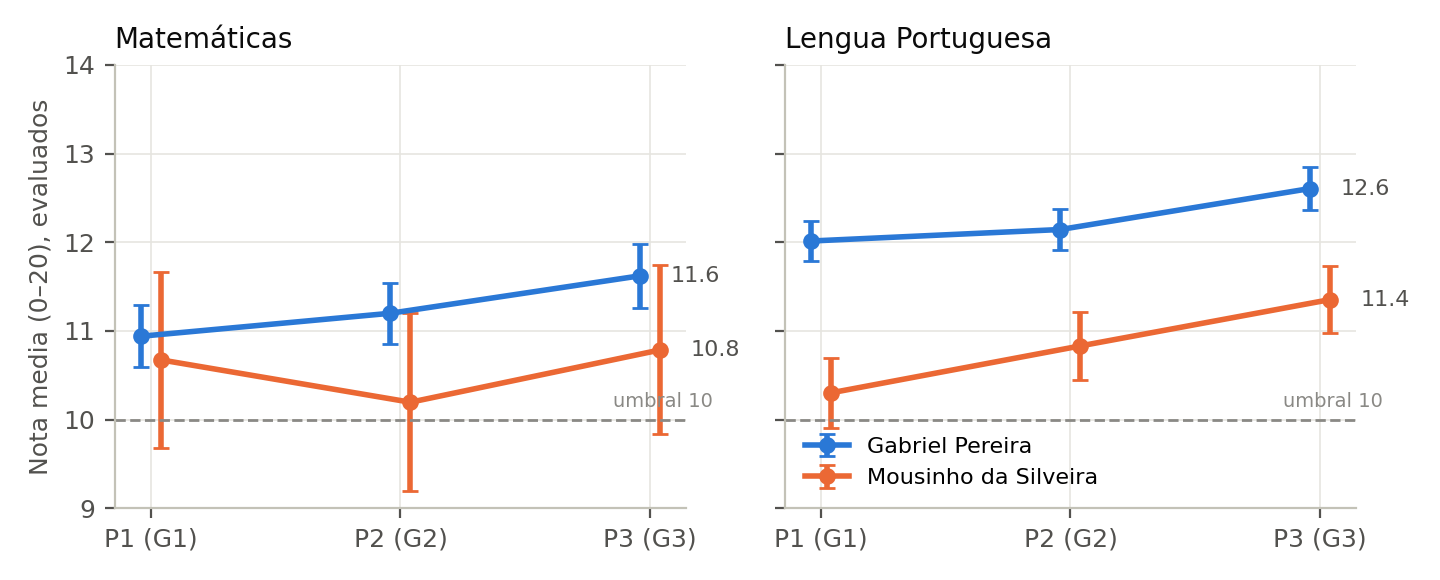

,asignatura,escuela,n,reprobados,tasa,ic_lo,ic_hi,prioridad
0,MAT,GP,349,113,0.323782,0.276840,0.374562,True
1,MAT,MS,46,17,0.369565,0.245238,0.513999,True
2,POR,GP,423,32,0.075650,0.054094,0.104845,False
3,POR,MS,226,68,0.300885,0.244826,0.363600,True


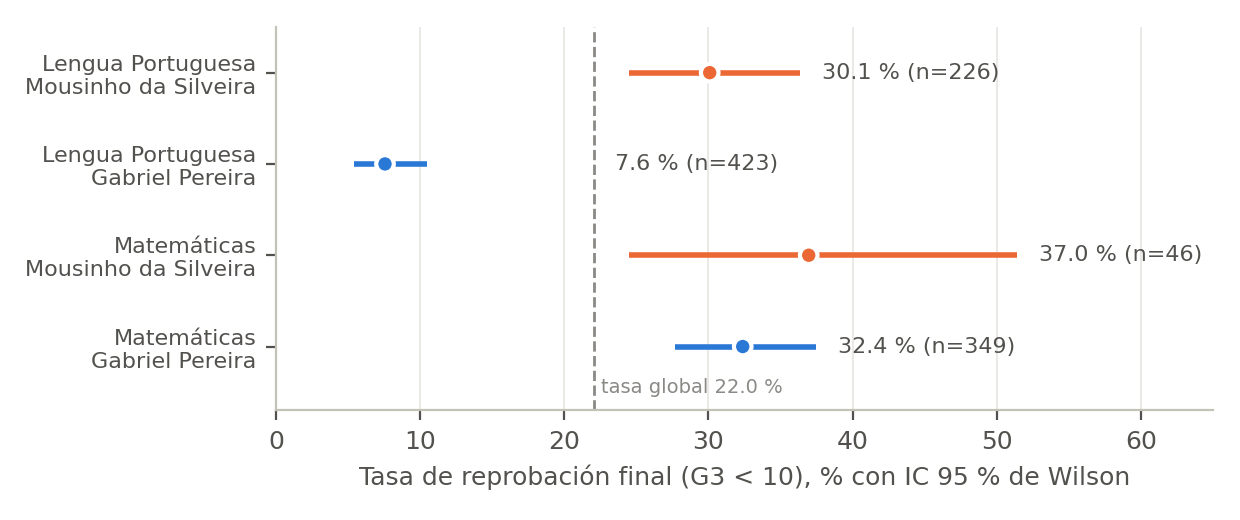

In [10]:
display(Image(filename=str(ROOT / 'informe/figuras/fig_p1_evolucion.png')))
display(pd.read_csv(ROOT / 'results/p1_reprobacion_escuela_asignatura.csv'))
display(Image(filename=str(ROOT / 'informe/figuras/fig_p1_reprobacion.png')))

,asignatura,etiqueta,prueba,p_holm,efecto,valor_efecto,ic_lo,ic_hi
0,MAT,Tiempo de estudio (1–4),Mann-Whitney U,0.998,δ de Cliff,0.060,-0.055,0.169
1,MAT,Faltas anuales,Mann-Whitney U,0.001,δ de Cliff,-0.226,-0.344,-0.111
2,MAT,Reprobaciones previas,Mann-Whitney U,0.001,δ de Cliff,-0.161,-0.234,-0.087
3,MAT,Refuerzo escolar (sí),Chi-cuadrado,0.000,V de Cramér,0.222,-0.220,-0.088
4,MAT,Clases pagadas (sí),Chi-cuadrado,0.998,V de Cramér,0.051,-0.161,0.049
5,MAT,Aspira a educación superior (sí),Chi-cuadrado,0.988,V de Cramér,0.068,-0.012,0.066
6,MAT,Minutos LMS en P1 [SIM],Mann-Whitney U,0.998,δ de Cliff,0.062,-0.059,0.181
7,MAT,Eventos LMS en P1 [SIM],Mann-Whitney U,0.998,δ de Cliff,0.071,-0.051,0.193
8,POR,Tiempo de estudio (1–4),Mann-Whitney U,0.000,δ de Cliff,0.255,0.173,0.334
9,POR,Faltas anuales,Mann-Whitney U,0.000,δ de Cliff,-0.221,-0.303,-0.138


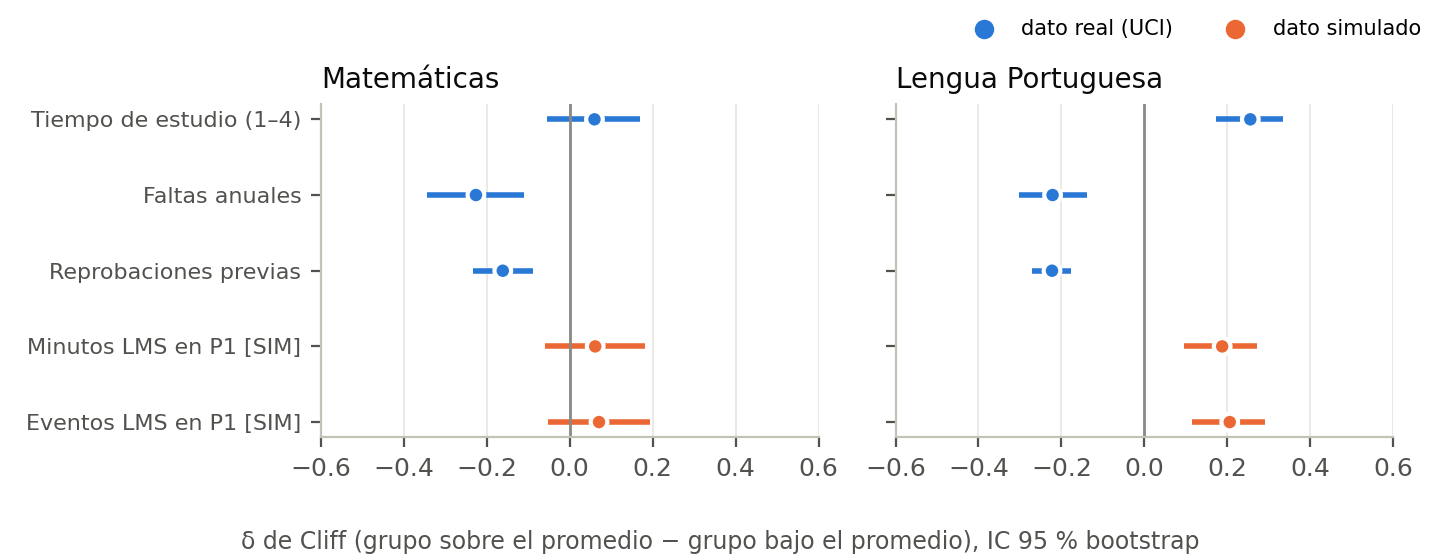

In [11]:
display(pd.read_csv(ROOT / 'results/p2_condiciones.csv')[['asignatura','etiqueta','prueba','p_holm','efecto','valor_efecto','ic_lo','ic_hi']].round(3))
display(Image(filename=str(ROOT / 'informe/figuras/fig_p2_cliff.png')))

,alta_inasistencia,reprob_previas,bajo_lms_sim,n,reprobados,tasa,ic_lo,ic_hi,sim_pct_con_alerta,sim_media_tutorias,sim_pct_con_tutoria,sim_pct_alerta_cerrada
0,False,True,True,42,21,0.500,0.355,0.645,0.810,1.500,0.595,0.357
1,True,True,True,30,15,0.500,0.332,0.668,0.533,1.333,0.533,0.367
2,True,True,False,41,20,0.488,0.343,0.635,0.512,0.976,0.439,0.366
3,False,True,False,41,16,0.390,0.257,0.543,0.585,1.073,0.512,0.390
4,True,False,True,44,12,0.273,0.163,0.418,0.318,0.295,0.182,0.205
5,True,False,False,164,29,0.177,0.126,0.242,0.183,0.390,0.159,0.116
6,False,False,True,124,18,0.145,0.094,0.218,0.258,0.508,0.234,0.185
7,False,False,False,505,46,0.091,0.069,0.119,0.143,0.309,0.141,0.091


,Unnamed: 0,OR,ic_lo,ic_hi,p,muestra,n
0,alta_inasistencia,1.766,1.221,2.554,0.003,faltas confiables (principal),991
1,reprob_previas,5.576,3.713,8.373,0.000,faltas confiables (principal),991
2,POR,0.447,0.317,0.628,0.000,faltas confiables (principal),991
3,alta_inasistencia,1.197,0.831,1.724,0.334,todas las matrículas (sensibilidad),1044
4,reprob_previas,6.867,4.727,9.976,0.000,todas las matrículas (sensibilidad),1044
5,POR,0.368,0.270,0.502,0.000,todas las matrículas (sensibilidad),1044


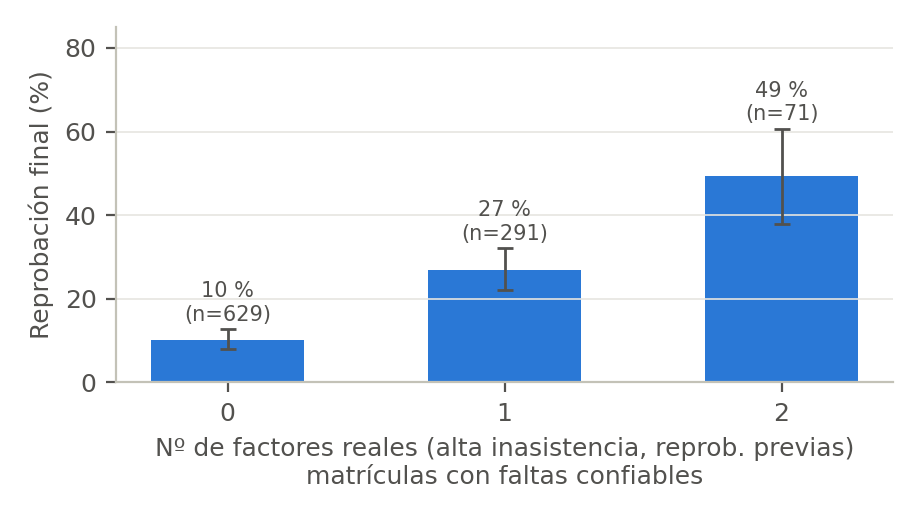

In [12]:
display(pd.read_csv(ROOT / 'results/principal_perfiles.csv').round(3))
display(pd.read_csv(ROOT / 'results/principal_or.csv').round(3))
display(Image(filename=str(ROOT / 'informe/figuras/fig_principal_factores.png')))

## 6. Modelo de predicción temprana: reproducción independiente del resultado principal

In [13]:
import analysis
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
esc = analysis.ESCENARIOS['A_corte_P1']
tr, te = df[df.particion == 'train'], df[df.particion == 'test']
m = analysis._pipe(esc, LogisticRegression(C=1.0, max_iter=2000)).fit(analysis._X(tr, esc), tr.en_riesgo)
auc = roc_auc_score(te.en_riesgo, m.predict_proba(analysis._X(te, esc))[:, 1])
ref = pd.read_csv(ROOT / 'results/modelo_metricas.csv').query("escenario=='A_corte_P1' and modelo=='Regresión logística'").auc_roc.iloc[0]
print(f'AUC test re-ajustado = {auc:.4f} | AUC reportado = {ref:.4f}')
assert abs(auc - ref) < 1e-6, 'El resultado no se reproduce'  # métrica guardada con 6 decimales

AUC test re-ajustado = 0.9482 | AUC reportado = 0.9482


,escenario,modelo,cv_auc_roc,auc_roc,auc_ic_lo,auc_ic_hi,auc_pr,recall,precision,f1,brier
0,C_matricula,Regresión logística,0.775,0.738,0.664,0.804,0.532,0.686,0.376,0.486,0.158
1,C_matricula,Random forest,0.799,0.750,0.676,0.817,0.563,0.667,0.378,0.482,0.154
2,C_matricula,Gradient boosting,0.785,0.762,0.689,0.824,0.557,0.745,0.358,0.484,0.153
3,A_corte_P1,Línea base (prior),0.500,0.500,0.500,0.500,0.241,0.000,0.000,0.000,0.183
4,A_corte_P1,Regresión logística,0.924,0.948,0.918,0.972,0.853,0.902,0.667,0.767,0.080
5,A_corte_P1,Random forest,0.921,0.940,0.904,0.969,0.845,0.882,0.714,0.789,0.097
6,A_corte_P1,Gradient boosting,0.925,0.944,0.915,0.968,0.830,0.922,0.671,0.777,0.083
7,B_corte_P2,Regresión logística,0.962,0.984,0.969,0.995,0.958,0.902,0.836,0.868,0.044
8,B_corte_P2,Random forest,0.962,0.988,0.975,0.996,0.965,0.882,0.882,0.882,0.055
9,B_corte_P2,Gradient boosting,0.962,0.984,0.968,0.996,0.960,0.902,0.885,0.893,0.041


,modelo,comparacion,delta_auc,ic_lo,ic_hi
0,Regresión logística,A_mas_sim − A_corte_P1,0.000,-0.004,0.004
1,Regresión logística,C_mas_sim − C_matricula,-0.000,-0.015,0.012
2,Regresión logística,A_mas_faltas − A_corte_P1,-0.003,-0.010,0.002
3,Regresión logística,B_corte_P2 − A_corte_P1,0.036,0.017,0.058
4,Regresión logística,A_corte_P1 − C_matricula,0.211,0.145,0.283
5,Random forest,A_mas_sim − A_corte_P1,0.005,-0.005,0.015
6,Random forest,C_mas_sim − C_matricula,0.005,-0.029,0.039
7,Random forest,A_mas_faltas − A_corte_P1,0.001,-0.008,0.010
8,Random forest,B_corte_P2 − A_corte_P1,0.047,0.021,0.079
9,Random forest,A_corte_P1 − C_matricula,0.190,0.127,0.261


,auc_C_honesto,auc_C_mas_sim_honesto,auc_C_mas_circular,auc_A_honesto,auc_A_mas_sim_honesto,auc_A_mas_circular
0,0.738,0.737,0.877,0.948,0.949,0.96


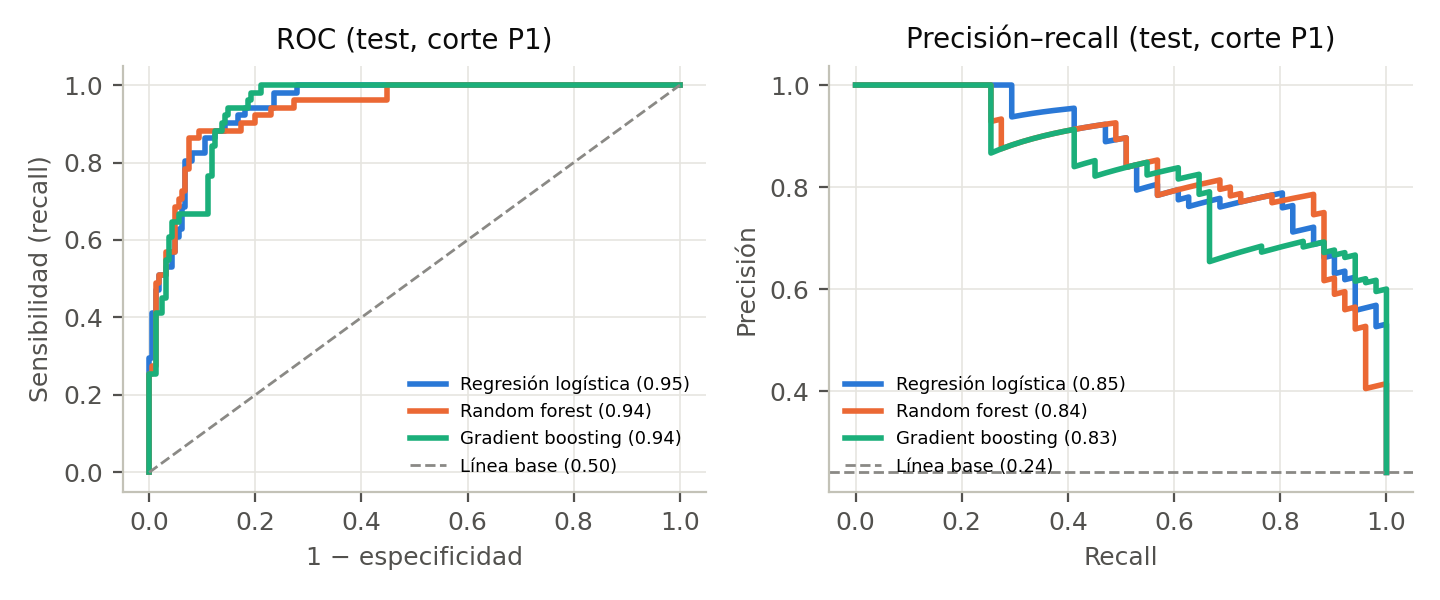

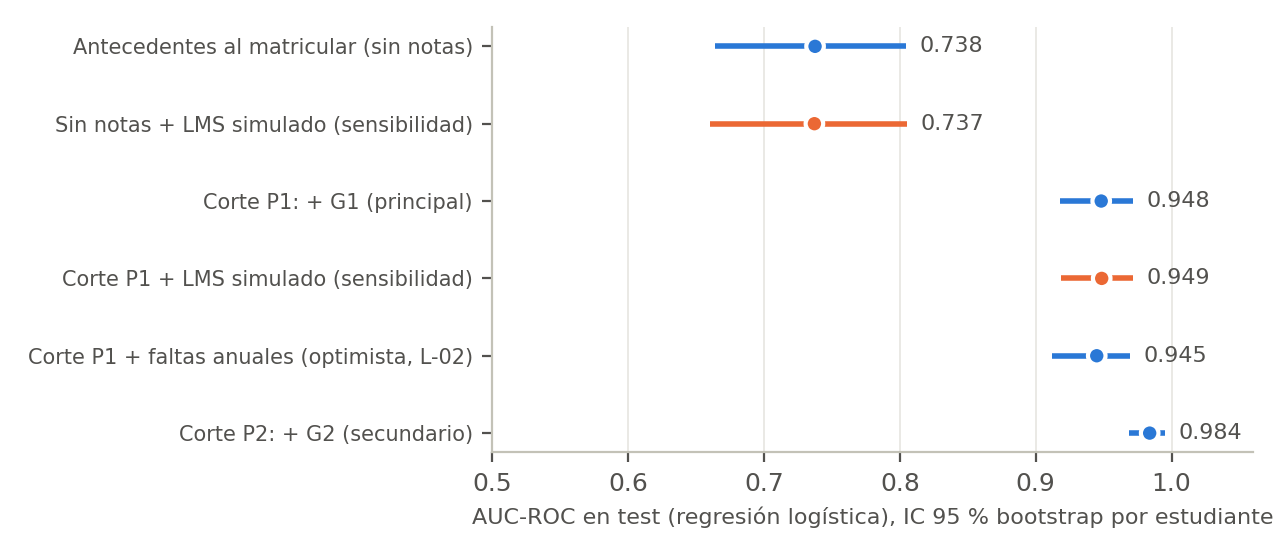

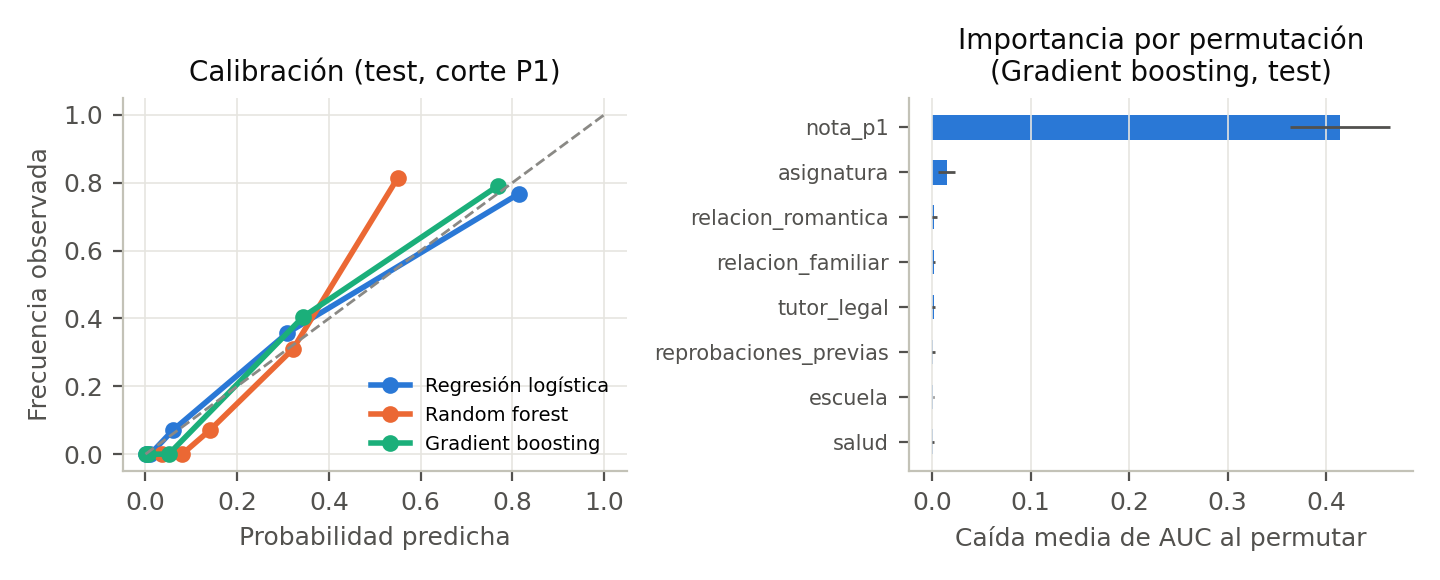

In [14]:
display(pd.read_csv(ROOT / 'results/modelo_metricas.csv')[['escenario','modelo','cv_auc_roc','auc_roc','auc_ic_lo','auc_ic_hi','auc_pr','recall','precision','f1','brier']].round(3))
display(pd.read_csv(ROOT / 'results/modelo_sensibilidad.csv').round(3))
display(pd.read_csv(ROOT / 'results/modelo_contrafactual_circular.csv').round(3))
display(Image(filename=str(ROOT / 'informe/figuras/fig_modelo_roc_pr.png')))
display(Image(filename=str(ROOT / 'informe/figuras/fig_modelo_escenarios.png')))
display(Image(filename=str(ROOT / 'informe/figuras/fig_modelo_calibracion_importancia.png')))

## 7. Escalabilidad (benchmark medido)

,factor,filas,grupos,memoria_bytes,bytes_por_fila,parquet_bytes,t_agregacion_s,t_escritura_s,t_lectura_s,filas_por_s_agregacion
0,1,47597,3086,905412,19.022,499822,0.008,0.015,0.002,5.859835e+06
1,10,475970,30860,9044499,19.002,1920937,0.031,0.027,0.005,1.515595e+07
2,100,4759700,308600,90435369,19.000,17612380,0.393,0.231,0.070,1.210751e+07
3,250,11899250,771500,226086819,19.000,43877158,1.208,0.614,0.187,9.847320e+06
4,500,23798500,1543000,452172569,19.000,87392611,2.674,1.219,0.303,8.901551e+06


,escenario,eventos_anuales,memoria_gb,t_agregacion_estimado_s,cabe_en_un_nodo_8gb
0,Caso actual (UCI),4.759700e+04,0.00,0.01,True
1,Red de 100 centros (100 000 est. × 10 asignatu...,4.559100e+07,0.87,5.12,True
2,Red nacional (1 000 000 est. × 10 asignaturas),4.559100e+08,8.66,51.22,False
3,Red nacional con clickstream (×20 eventos),9.118199e+09,173.25,1024.34,False


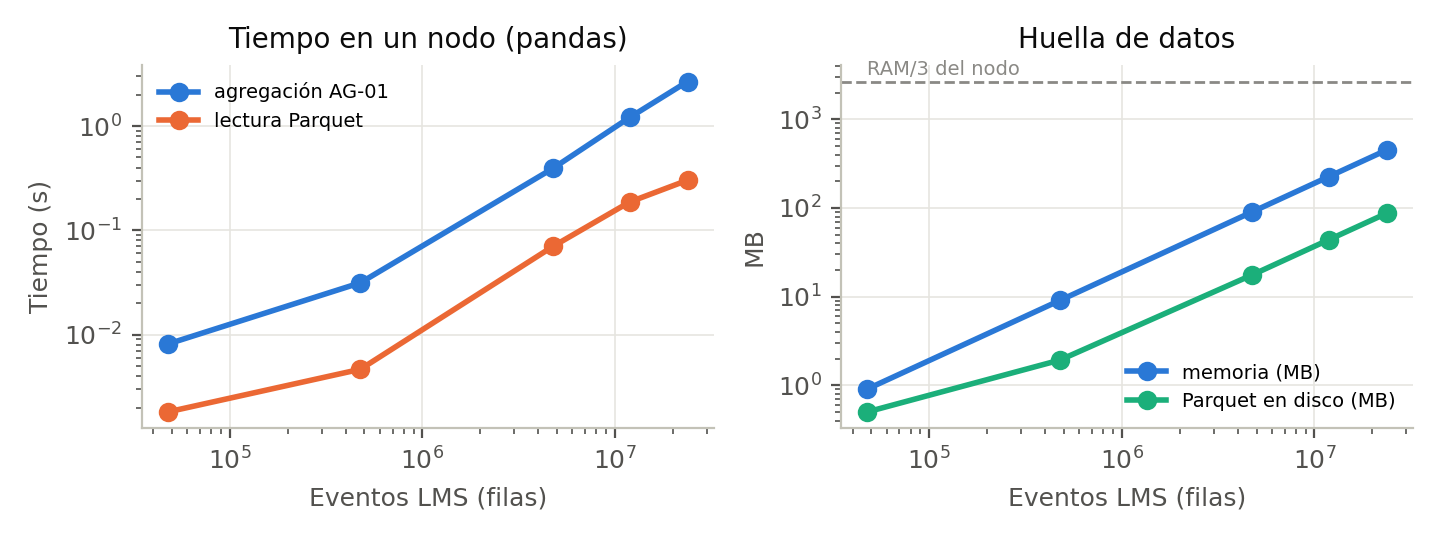

In [15]:
display(pd.read_csv(ROOT / 'results/escalabilidad.csv').round(3))
display(pd.read_csv(ROOT / 'results/escalabilidad_escenarios.csv').round(2))
display(Image(filename=str(ROOT / 'informe/figuras/fig_escalabilidad.png')))